<a href="https://colab.research.google.com/github/DengDuangLang111/494-algo-representations/blob/week2/task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install polars ctranslate2 transformers tqdm huggingface_hub

In [ ]:
import os

model_dir = "m2m100_ct2_int8"

print("Converting model...")

# Use --force to overwrite output directory if it exists
!ct2-transformers-converter --model facebook/m2m100_418M \
    --output_dir {model_dir} \
    --copy_files sentencepiece.bpe.model tokenizer_config.json vocab.json \
    --quantization int8_float16 --force

# Verify output
if os.path.exists(os.path.join(model_dir, "model.bin")):
    print("Conversion successful.")
else:
    print("Conversion failed.")

In [ ]:
import polars as pl
import ctranslate2
import transformers
from tqdm import tqdm
import os
import queue
import threading
import time
from google.colab import files

def run_step2():
    # Path configuration
    # Ensure directory exists
    if not os.path.exists("/content/data"):
        os.makedirs("/content/data")

    INPUT_PATH = "/content/data/notes_with_lang.parquet"
    OUTPUT_PATH = "/content/data/notes_translated_final.parquet"
    MODEL_DIR = "m2m100_ct2_int8"
    TOKENIZER_ID = "facebook/m2m100_418M"

    # A100 optimization parameters
    TARGET_BATCH_TOKENS = 960000
    CT2_MAX_BATCH_SIZE = 1000000
    QUEUE_MAX_SIZE = 200

    LANG_MAPPING = {
        'eng_Latn': 'en', 'spa_Latn': 'es', 'por_Latn': 'pt', 'fra_Latn': 'fr',
        'deu_Latn': 'de', 'jpn_Jpan': 'ja', 'kor_Hang': 'ko', 'tur_Latn': 'tr',
        'pol_Latn': 'pl', 'ita_Latn': 'it', 'rus_Cyrl': 'ru', 'zho_Hans': 'zh',
        'zho_Hant': 'zh', 'yue_Hant': 'zh', 'arb_Arab': 'ar', 'hin_Deva': 'hi',
        'nld_Latn': 'nl', 'ind_Latn': 'id', 'vie_Latn': 'vi', 'tha_Thai': 'th',
        'ell_Grek': 'el', 'heb_Hebr': 'he', 'swe_Latn': 'sv', 'dan_Latn': 'da',
        'fin_Latn': 'fi', 'nor_Latn': 'no', 'ces_Latn': 'cs', 'hun_Latn': 'hu'
    }

    if not os.path.exists(MODEL_DIR):
        print(f"Model directory not found: {MODEL_DIR}")
        return

    print(f"Starting C++ Inference Engine (A100 Optimized)...")
    translator = ctranslate2.Translator(
        MODEL_DIR,
        device="cuda",
        device_index=[0],
        compute_type="int8_float16",
        inter_threads=4,          # Set to 1 for stability with high beam size
        intra_threads=16
    )

    print("Loading data...")
    if not os.path.exists(INPUT_PATH):
        print(f"Input file not found: {INPUT_PATH}")
        return

    df = pl.read_parquet(INPUT_PATH).drop_nulls(subset=['summary', 'note_language'])
    df = df.with_columns(pl.col("note_language").map_elements(lambda x: LANG_MAPPING.get(x, "unknown"), return_dtype=pl.String).alias("m2m_lang"))

    english_df = df.filter(pl.col("m2m_lang") == "en")
    unknown_df = df.filter(pl.col("m2m_lang") == "unknown")
    to_translate_df = df.filter((pl.col("m2m_lang") != "en") & (pl.col("m2m_lang") != "unknown"))

    task_count = len(to_translate_df)
    print(f"Tasks to translate: {task_count}")
    if task_count == 0: return

    # Stage 1: Producer (Tokenizer)
    def tokenizer_worker(df_to_proc, q_out):
        try:
            local_tokenizer = transformers.AutoTokenizer.from_pretrained(TOKENIZER_ID)
            lang_groups = df_to_proc.partition_by("m2m_lang", as_dict=True)
            for lang_key, lang_df in lang_groups.items():
                src_lang = lang_key[0] if isinstance(lang_key, tuple) else lang_key
                local_tokenizer.src_lang = src_lang

                temp_df = lang_df.with_columns(pl.col("summary").str.len_chars().alias("len")).sort("len")
                all_texts = temp_df["summary"].to_list()
                all_ids = temp_df["noteId"].to_list()
                all_lens = temp_df["len"].to_list()

                curr_texts, curr_ids, curr_len = [], [], 0

                for text, note_id, text_len in zip(all_texts, all_ids, all_lens):
                    curr_texts.append(text)
                    curr_ids.append(note_id)
                    curr_len += (text_len + 5)

                    if curr_len >= TARGET_BATCH_TOKENS:
                        batch_enc = local_tokenizer(curr_texts, add_special_tokens=True, truncation=True, max_length=256)
                        source_tokens = [local_tokenizer.convert_ids_to_tokens(ids) for ids in batch_enc["input_ids"]]
                        prefix_token = local_tokenizer.lang_code_to_token["en"]
                        target_prefix = [[prefix_token] for _ in range(len(curr_texts))]

                        q_out.put({"source_tokens": source_tokens, "target_prefix": target_prefix, "note_ids": curr_ids})
                        curr_texts, curr_ids, curr_len = [], [], 0

                if curr_texts:
                    batch_enc = local_tokenizer(curr_texts, add_special_tokens=True, truncation=True, max_length=256)
                    source_tokens = [local_tokenizer.convert_ids_to_tokens(ids) for ids in batch_enc["input_ids"]]
                    target_prefix = [[local_tokenizer.lang_code_to_token["en"]] for _ in range(len(curr_texts))]
                    q_out.put({"source_tokens": source_tokens, "target_prefix": target_prefix, "note_ids": curr_ids})

        except Exception as e:
            print(f"Tokenizer thread error: {e}")
        finally:
            q_out.put(None)

    # Stage 3: Consumer (Decoder)
    def decoder_worker(q_in, results_list, pbar_obj):
        try:
            local_tokenizer = transformers.AutoTokenizer.from_pretrained(TOKENIZER_ID)
            while True:
                item = q_in.get()
                if item is None: break
                hypotheses = item["hypotheses"]
                note_ids = item["note_ids"]
                decoded_texts = [local_tokenizer.convert_tokens_to_string(h) for h in hypotheses]
                results_list.extend(zip(note_ids, decoded_texts))
                pbar_obj.update(len(note_ids))
                q_in.task_done()
        except Exception as e:
            print(f"Decoder thread error: {e}")

    # GPU Main Loop
    token_queue = queue.Queue(maxsize=QUEUE_MAX_SIZE)
    raw_result_queue = queue.Queue(maxsize=QUEUE_MAX_SIZE)
    final_results = []

    pbar = tqdm(total=task_count, desc="Translating", unit="note", dynamic_ncols=True)
    t_tokenize = threading.Thread(target=tokenizer_worker, args=(to_translate_df, token_queue))
    t_decode = threading.Thread(target=decoder_worker, args=(raw_result_queue, final_results, pbar))
    t_tokenize.start()
    t_decode.start()

    try:
        while True:
            item = token_queue.get()
            if item is None:
                raw_result_queue.put(None)
                break

            results = translator.translate_batch(
                item["source_tokens"],
                target_prefix=item["target_prefix"],
                beam_size=1,  # Beam size configuration
                return_scores=False,
                max_batch_size=CT2_MAX_BATCH_SIZE,
                batch_type="tokens"
            )

            hypotheses = [res.hypotheses[0] for res in results]
            raw_result_queue.put({"hypotheses": hypotheses, "note_ids": item["note_ids"]})
    except Exception as e:
        print(f"GPU loop error: {e}")
    finally:
        t_tokenize.join()
        t_decode.join()
        pbar.close()

    # Save and Download
    if len(final_results) > 0:
        print("Merging data and saving...")
        translated_df_part = pl.DataFrame(final_results, schema={"noteId": pl.Int64, "translated_en": pl.String}, orient="row")
        result_df = to_translate_df.join(translated_df_part, on="noteId", how="left")
        processed_en = english_df.select(["noteId", "summary", "note_language"]).with_columns(pl.col("summary").alias("translated_en"))
        processed_unknown = unknown_df.select(["noteId", "summary", "note_language"]).with_columns(pl.col("summary").alias("translated_en"))
        final_result_df = result_df.select(["noteId", "summary", "note_language", "translated_en"])
        final_df = pl.concat([processed_en, processed_unknown, final_result_df], how="vertical")
        final_df.write_parquet(OUTPUT_PATH)
        print(f"Done! Saved to: {OUTPUT_PATH}")
        files.download(OUTPUT_PATH)

if __name__ == "__main__":
    run_step2()

In [ ]:
import pandas as pd
from transformers import pipeline, AutoModelForSequenceClassification, AutoTokenizer
from tqdm.auto import tqdm
import torch
import gc

# Load data
df = pd.read_parquet('/content/data/notes_translated_final.parquet')
texts = df['translated_en'].tolist()

def data_generator():
    for text in texts:
        yield str(text) if text is not None else ""

# Load model with SDPA acceleration
print("Loading model with SDPA acceleration...")
model_id = "cardiffnlp/tweet-topic-latest-multi"

# Enable SDPA for fast inference
model = AutoModelForSequenceClassification.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    attn_implementation="sdpa"
).to("cuda")

tokenizer = AutoTokenizer.from_pretrained(model_id)

# Initialize pipeline
topic_classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0,
    batch_size=256,    # Large batch size for A100
    truncation=True,
    max_length=256
)

# Run inference
print(f"Processing {len(texts)} texts...")
final_labels = []

# Use sigmoid for multi-label classification
for out in tqdm(
    topic_classifier(data_generator(), top_k=None, function_to_apply="sigmoid"),
    total=len(texts)
):
    labels = [res["label"] for res in out if res["score"] >= 0.5]
    final_labels.append(labels)

# Save results
df['topic_labels'] = final_labels
intermediate_path = '/content/data/notes_step2_topics.parquet'
df.to_parquet(intermediate_path)

print(f"Done. Saved to: {intermediate_path}")

# Cleanup GPU memory
del topic_classifier, model
torch.cuda.empty_cache()
gc.collect()

In [ ]:
import pandas as pd
import torch
import gc
from tqdm.auto import tqdm
from datasets import Dataset
from transformers.pipelines.pt_utils import KeyDataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

# 1. Configuration
IN_PATH  = "/content/data/notes_step2_topics.parquet"
OUT_PATH = "/content/data/notes_labeled_final.parquet"

TEXT_COL  = "translated_en"
TOPIC_COL = "topic_labels"
POL_LABEL = "news_&_social_concern"

MODEL_ID = "manifesto-project/manifestoberta-xlm-roberta-56policy-topics-sentence-2024-1-1"
TOKENIZER_ID = "xlm-roberta-large"

# A100 Optimization settings
BATCH_SIZE = 2048
MAX_LEN = 200
NUM_WORKERS = 8
DTYPE = torch.bfloat16

# 2. Load and Filter Data
print("Loading data...")
df = pd.read_parquet(IN_PATH)

def has_news_social_robust(x):
    if x is None: return False
    return POL_LABEL in str(x)

mask = df[TOPIC_COL].apply(has_news_social_robust)
df_political = df.loc[mask, [TEXT_COL]].copy()

print(f"Total rows: {len(df)}, Political rows: {len(df_political)}")

if len(df_political) == 0:
    print("No political notes found. Check input data.")
else:
    # 3. Load Model
    print("Loading model...")

    # Load tokenizer explicitly
    tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_ID)

    # Load model with SDPA acceleration
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_ID,
        torch_dtype=DTYPE,
        attn_implementation="sdpa"
    ).to("cuda").eval()

    # Initialize pipeline
    policy_pipe = pipeline(
        "text-classification",
        model=model,
        tokenizer=tokenizer,
        device=0,
        batch_size=BATCH_SIZE,
        truncation=True,
        max_length=MAX_LEN,
    )

    # 4. Inference
    ds = Dataset.from_pandas(df_political[[TEXT_COL]], preserve_index=True)
    it = KeyDataset(ds, TEXT_COL)

    policy_topic = [None] * len(df_political)
    policy_score = [None] * len(df_political)

    print("Running classification...")
    outputs = policy_pipe(it, function_to_apply="softmax", num_workers=NUM_WORKERS)

    for i, out in enumerate(tqdm(outputs, total=len(df_political), desc="Progress")):
        policy_topic[i] = out["label"]
        policy_score[i] = float(out["score"])

    # 5. Save Results
    print("Saving...")
    df.loc[mask, "policy_topic"] = policy_topic
    df.loc[mask, "policy_score"] = policy_score

    df.to_parquet(OUT_PATH, index=False)
    print(f"Done. Saved to: {OUT_PATH}")

    # 6. Cleanup
    del policy_pipe, model
    torch.cuda.empty_cache()
    gc.collect()

Found classification file and 1 rating file(s).
Processing notes data...
Processing ratings data...
Reading ratings-00002.tsv...
Preparing visualization...
Figure saved to: /content/data/Figure_S10_Final_Combined.svg


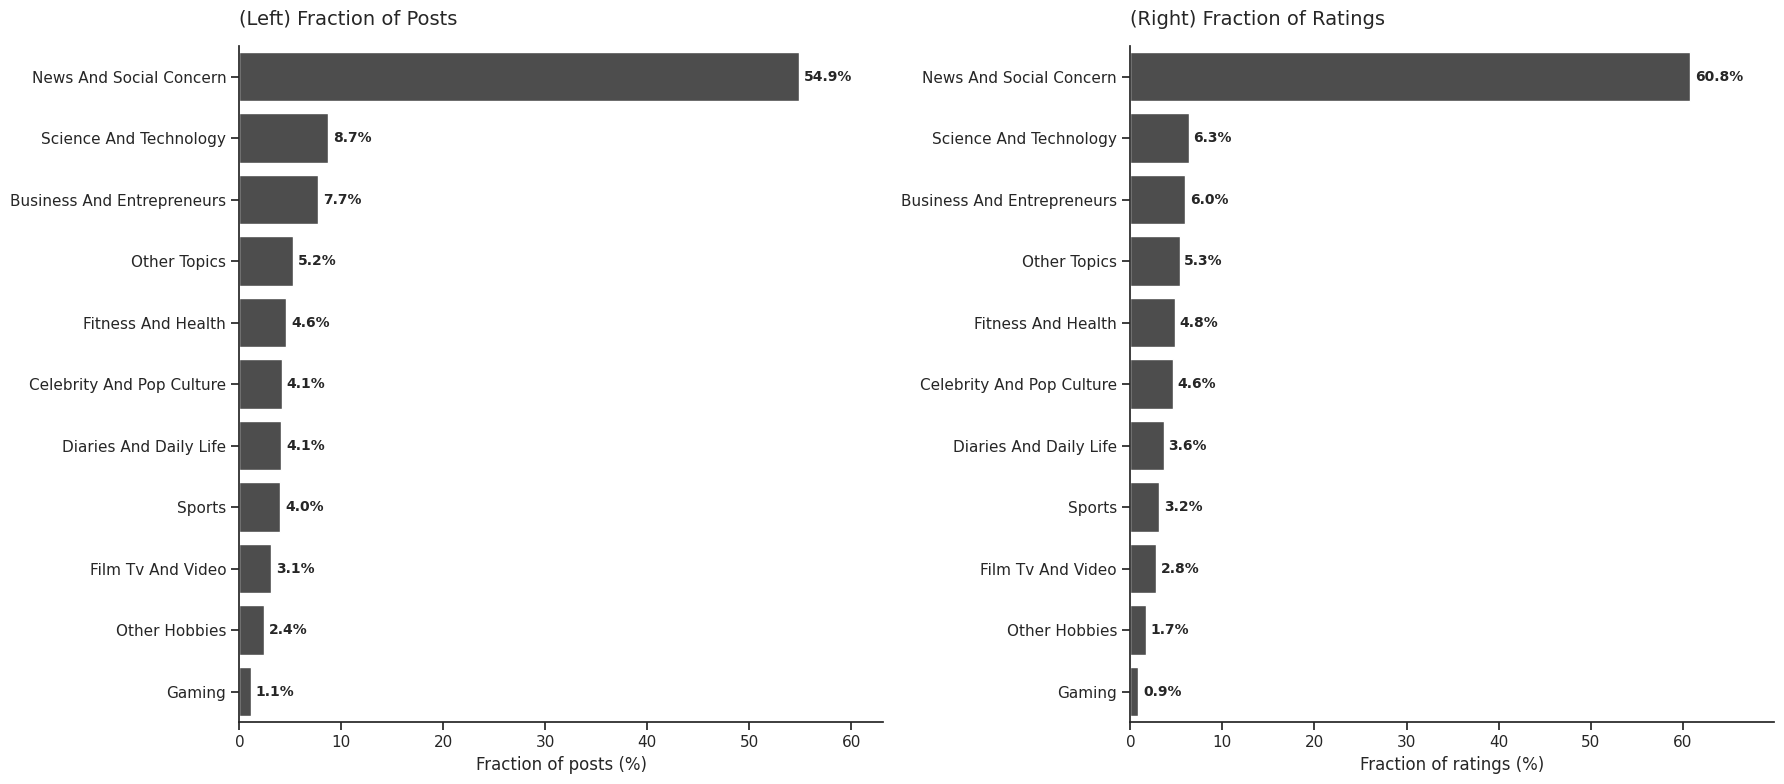

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# 1. Setup Paths
DATA_DIR = Path("/content/data")
labeled_file = DATA_DIR / "notes_labeled_final.parquet"
rating_files = list(DATA_DIR.glob("ratings-*.tsv"))

if not labeled_file.exists():
    print(f"Error: {labeled_file} not found.")
    sys.exit(1)

if not rating_files:
    print(f"Error: No ratings-*.tsv files found in {DATA_DIR}.")
    sys.exit(1)

print(f"Found classification file and {len(rating_files)} rating file(s).")

# 2. Process Notes Data (Left Chart Source)
print("Processing notes data...")
notes_df = pd.read_parquet(labeled_file)
notes_exploded = notes_df.explode("topic_labels").dropna(subset=["topic_labels"])
notes_exploded["noteId"] = notes_exploded["noteId"].astype(str).str.strip()

# 3. Process Ratings Data (Right Chart Source)
print("Processing ratings data...")
note_topic_df = notes_exploded[["noteId", "topic_labels"]].copy()

# Initialize counters
top_topics = notes_exploded["topic_labels"].value_counts().head(10).index.tolist()
top_counts = pd.Series(0, index=top_topics, dtype="int64")
other_count = 0

for f in rating_files:
    print(f"Reading {f.name}...")
    reader = pd.read_csv(
        f,
        sep="\t",
        usecols=["noteId"],
        chunksize=2_000_000,
        dtype={"noteId": str},
        on_bad_lines='skip'
    )

    for chunk in reader:
        chunk["noteId"] = chunk["noteId"].str.strip()
        merged = chunk.merge(note_topic_df, on="noteId", how="inner")

        vc = merged["topic_labels"].value_counts()

        top_counts = top_counts.add(vc.reindex(top_topics, fill_value=0), fill_value=0).astype("int64")

        current_total = int(vc.sum())
        current_top = int(vc.reindex(top_topics, fill_value=0).sum())
        other_count += (current_total - current_top)

# Assemble Right Chart Data
final_counts = top_counts.copy()
final_counts["Other Topics"] = other_count
df_right = final_counts.reset_index()
df_right.columns = ["Topic", "Count"]
df_right["Fraction"] = df_right["Count"] / df_right["Count"].sum() * 100
df_right = df_right.sort_values("Fraction", ascending=False)
df_right["Topic"] = df_right["Topic"].str.replace("_", " ").str.title().str.replace(" & ", " And ")

# 4. Assemble Left Chart Data
print("Preparing visualization...")
post_counts = notes_exploded["topic_labels"].value_counts()
top_10_posts = post_counts.head(10)
other_posts = post_counts.iloc[10:].sum()

df_left = pd.concat([top_10_posts, pd.Series({"Other Topics": other_posts})]).reset_index()
df_left.columns = ["Topic", "Count"]
df_left["Fraction"] = df_left["Count"] / df_left["Count"].sum() * 100
df_left = df_left.sort_values("Fraction", ascending=False)
df_left["Topic"] = df_left["Topic"].str.replace("_", " ").str.title().str.replace(" & ", " And ")

# 5. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
sns.set_theme(style="ticks")

# Left Plot: Posts
sns.barplot(data=df_left, x="Fraction", y="Topic", color="#4D4D4D", ax=ax1)
for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.1f}%',
                 (p.get_width() + 0.5, p.get_y() + p.get_height()/2),
                 va='center', fontsize=10, fontweight='bold')
ax1.set_title("(Left) Fraction of Posts", loc='left', fontsize=14, pad=15)
ax1.set_xlabel("Fraction of posts (%)", fontsize=12)
ax1.set_ylabel("")
ax1.set_xlim(0, max(df_left["Fraction"]) * 1.15)

# Right Plot: Ratings
sns.barplot(data=df_right, x="Fraction", y="Topic", color="#4D4D4D", ax=ax2)
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.1f}%',
                 (p.get_width() + 0.5, p.get_y() + p.get_height()/2),
                 va='center', fontsize=10, fontweight='bold')
ax2.set_title("(Right) Fraction of Ratings", loc='left', fontsize=14, pad=15)
ax2.set_xlabel("Fraction of ratings (%)", fontsize=12)
ax2.set_ylabel("")
ax2.set_xlim(0, max(df_right["Fraction"]) * 1.15)

sns.despine()
plt.tight_layout()

save_path = DATA_DIR / "Figure_S10_Final_Combined.svg"
plt.savefig(save_path)
print(f"Figure saved to: {save_path}")
plt.show()

In [ ]:
def _():
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from pathlib import Path

    # 1. Locate data directory
    current_dir = Path.cwd()
    possible_paths = [Path("../../data"), Path("data"), Path("D:/494/494-algo-representations/data")]
    DATA_DIR = None
    for p in possible_paths:
        if p.exists() and (p / "notes_labeled_final.parquet").exists():
            DATA_DIR = p
            break

    if DATA_DIR is None:
        raise FileNotFoundError("Data directory not found.")

    # 2. Read note status history
    history_file = DATA_DIR / "noteStatusHistory-00000.tsv"
    print(f"Reading history: {history_file.name} ...")

    df_history = pd.read_csv(
        history_file,
        sep="\t",
        usecols=["noteId", "currentStatus", "createdAtMillis"],
        dtype={"noteId": str, "currentStatus": str, "createdAtMillis": float},
        on_bad_lines='skip'
    )

    print("Extracting latest status...")
    df_latest = df_history.sort_values("createdAtMillis", ascending=False).drop_duplicates("noteId", keep="first")

    # Normalize status labels to match color mapping
    print("Normalizing status names...")
    df_latest["currentStatus"] = df_latest["currentStatus"].replace({
        "CURRENTLY_RATED_HELPFUL": "HELPFUL",
        "CURRENTLY_RATED_NOT_HELPFUL": "NOT_HELPFUL",
        "NEEDS_MORE_RATINGS": "NEEDS_MORE_RATINGS"
    })

    # 3. Load topics and merge
    df_topics = pd.read_parquet(DATA_DIR / "notes_labeled_final.parquet")
    df_topics = df_topics.explode("topic_labels").dropna(subset=["topic_labels"])
    df_topics["noteId"] = df_topics["noteId"].astype(str).str.strip()

    print("Merging data...")
    merged = df_topics.merge(df_latest[["noteId", "currentStatus"]], on="noteId", how="inner")
    print(f"   -> Merged {len(merged)} records")

    # 4. Plot outcomes
    if len(merged) > 0:
        print("Plotting...")
        counts = merged.groupby(["topic_labels", "currentStatus"]).size().unstack(fill_value=0)
        props = counts.div(counts.sum(axis=1), axis=0) * 100

        # Sort by Helpful percentage
        if "HELPFUL" in props.columns:
            props = props.sort_values("HELPFUL", ascending=False)
        else:
            props = props.sort_values(props.columns[0], ascending=False)

        props.index = props.index.str.replace("_", " ").str.title().str.replace(" & ", " And ")

        # Color mapping
        color_map = {
            "HELPFUL": "#4ade80",           # Green
            "NOT_HELPFUL": "#f87171",       # Red
            "NEEDS_MORE_RATINGS": "#60a5fa" # Blue
        }

        # Enforce column order
        col_order = ["HELPFUL", "NOT_HELPFUL", "NEEDS_MORE_RATINGS"]
        final_cols = [c for c in col_order if c in props.columns]

        fig, ax = plt.subplots(figsize=(16, 8))
        left_padding = pd.Series(0.0, index=props.index)

        for status in final_cols:
            data = props[status]
            c = color_map.get(status, "#999999")

            ax.barh(props.index, data, left=left_padding, color=c, label=status.replace("_", " "), height=0.8)

            # Annotate bars if percentage > 3%
            for idx, val in enumerate(data):
                if val > 3.0:
                    x_pos = left_padding.iloc[idx] + val / 2
                    # Use white text for red background, black otherwise
                    text_color = 'white' if status == "NOT_HELPFUL" else 'black'
                    ax.text(x_pos, idx, f"{val:.1f}%", va='center', ha='center', fontsize=9, color=text_color, fontweight='bold')

            left_padding += data

        ax.set_title(f"Community Note Outcomes by Topic (N={len(merged)})", fontsize=15)
        ax.set_xlabel("Outcomes (%)", fontsize=12)
        ax.set_xlim(0, 100)
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, frameon=False)

        sns.despine(left=True, bottom=False)
        ax.tick_params(axis='y', length=0)
        plt.subplots_adjust(left=0.25) # Adjust layout to prevent clipping

        save_path = DATA_DIR / "Figure_Outcome_Full.svg"
        plt.savefig(save_path, bbox_inches="tight")
        print(f"Chart saved to: {save_path}")
    return plt.show()

_()